In [1]:
import pandas as pd
import numpy as np 

In [4]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [6]:
df = pd.read_csv('train.csv', usecols=['Age', 'Fare', 'Survived'])

In [8]:
df.dropna(inplace=True)

In [9]:
df.shape

(714, 3)

In [10]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [18]:
x = df.iloc[:,1:]
y = df.iloc[:,0]

In [20]:
# Features
X = df[['Age', 'Fare']]

# Target
y = df['Survived']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(571, 2)
(143, 2)


In [22]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [23]:
clf = DecisionTreeClassifier()

In [24]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [25]:
accuracy_score(y_test, y_pred)

0.6433566433566433

In [26]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6275039123630674)

In [35]:
from sklearn.preprocessing import KBinsDiscretizer

kbin_age = KBinsDiscretizer(
    n_bins=5,
    encode='ordinal',
    strategy='kmeans'
)

kbin_fare = KBinsDiscretizer(
    n_bins=5,
    encode='ordinal',
    strategy='kmeans'
)
trf = ColumnTransformer(
    transformers=[
        ('age', kbin_age, [0]), # 0 & 1 is used for the columns to represent
        ('fare', kbin_fare, [1])
    ]
)

In [36]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [40]:
trf.named_transformers_['age'].bin_edges_

array([array([ 0.42      , 12.69636862, 27.02765256, 39.35418895, 54.21464646,
              80.        ])                                                   ],
      dtype=object)

In [43]:
output = pd.DataFrame({
    'age': X_train['Age'],
    'age_trf': X_train_trf[:,0],
    'fare': X_train['Fare'],
    'fare_trf': X_train_trf[:,1]
})

In [45]:
output['age_labels'] = pd.cut(
    x=X_train['Age'],
    bins=trf.named_transformers_['age'].bin_edges_[0].tolist()
)

output['fare_labels'] = pd.cut(
    x=X_train['Fare'],
    bins=trf.named_transformers_['fare'].bin_edges_[0].tolist()
)

In [46]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
197,42.0,3.0,8.4042,0.0,"(39.354, 54.215]","(0.0, 42.424]"
371,18.0,1.0,6.4958,0.0,"(12.696, 27.028]","(0.0, 42.424]"
809,33.0,2.0,53.1000,1.0,"(27.028, 39.354]","(42.424, 100.624]"
874,28.0,2.0,24.0000,0.0,"(27.028, 39.354]","(0.0, 42.424]"
160,44.0,3.0,16.1000,0.0,"(39.354, 54.215]","(0.0, 42.424]"


In [47]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf, y_train)
y_pred2 = clf.predict(X_test_trf)

In [48]:
accuracy_score(y_test,y_pred2)

0.6223776223776224

In [49]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6345070422535212)

In [50]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()

0.630281690140845


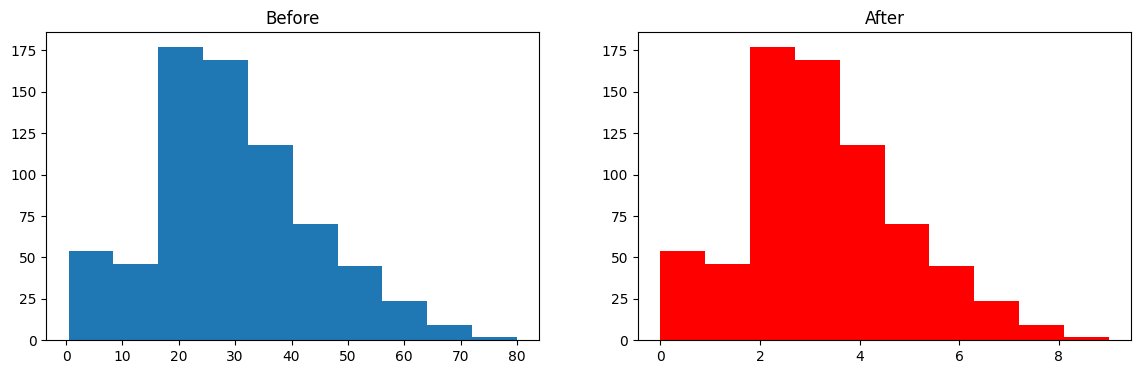

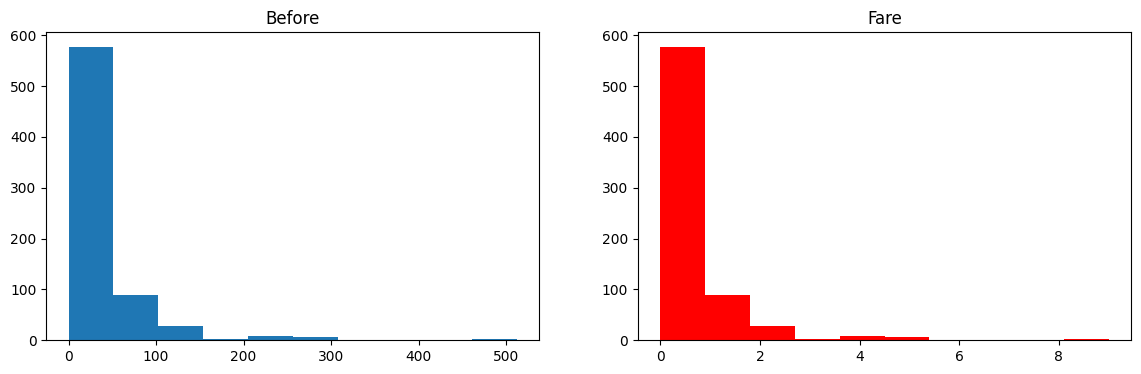

In [52]:
discretize(10,'uniform')